c:\Users\amaca253\AppData\Local\anaconda3\envs\datomatisation\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


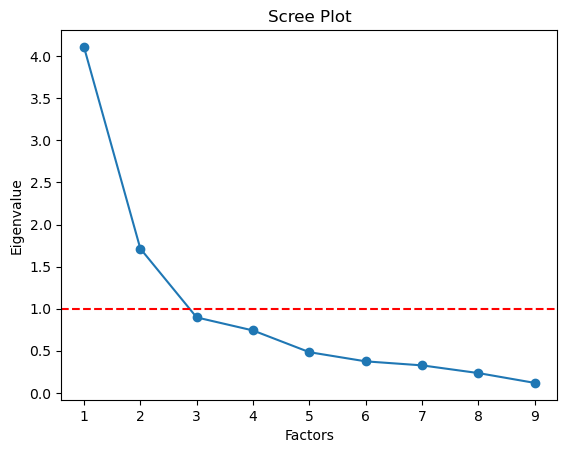

Factor Loadings:
                                        Factor 1  Factor 2  Factor 3  Factor 4
npxG_adjusted_per90                   -0.160197  0.705606  0.020638  0.039080
final_third_passes_adjusted_per90      0.898870 -0.125602  0.158390 -0.158904
final_third_receptions_adjusted_per90  0.881194  0.013193  0.197516 -0.024435
ground_duels_won_adjusted_per90        0.648110 -0.184365 -0.035262 -0.197185
air_duels_won_adjusted_per90          -0.327973 -0.033589 -0.113944  0.934554
smart_passes_adjusted_per90            0.775683  0.000168  0.070957 -0.195362
goals_adjusted_per90                   0.092911  0.980026 -0.049342 -0.075484
assists_adjusted_per90                 0.232441 -0.021508  0.964799 -0.101991
key_passes_adjusted_per90              0.729985  0.052899  0.159760 -0.141659


c:\Users\amaca253\AppData\Local\anaconda3\envs\datomatisation\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [6]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

# Load the data (assuming the CSV contains the columns listed in the sources)
# Columns: npxG_adjusted_per90, final_third_passes_adjusted_per90, 
# final_third_receptions_adjusted_per90, ground_duels_won_adjusted_per90, 
# air_duels_won_adjusted_per90, smart_passes_adjusted_per90, 
# goals_adjusted_per90, assists_adjusted_per90, key_passes_adjusted_per90
df = pd.read_csv('/data/demo_data/football/Forwards.csv', encoding='latin-1')
df_numeric = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Minutes'])

# 1. Determine the number of factors using Kaiser Criterion (Eigenvalues > 1)
fa = FactorAnalyzer(rotation=None)
fa.fit(df_numeric)
ev, v = fa.get_eigenvalues()

# Scree plot to visualize the best number of factors
plt.scatter(range(1, df_numeric.shape[1]+1), ev)
plt.plot(range(1, df_numeric.shape[1]+1), ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--')
plt.show()

# 2. Perform Factor Analysis with 4 factors and Varimax rotation
fa_final = FactorAnalyzer(n_factors=4, rotation="varimax")
fa_final.fit(df_numeric)

# 3. Display Factor Loadings to name factors
loadings = pd.DataFrame(fa_final.loadings_, 
                        index=df_numeric.columns, 
                        columns=['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4'])
print("Factor Loadings:\n", loadings)

In [8]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load data based on the metrics in the sources
# Sources include: npxG, final_third_passes, air_duels_won, ground_duels_won, etc.

cols = ['npxG_adjusted_per90', 'final_third_passes_adjusted_per90', 
        'final_third_receptions_adjusted_per90', 'ground_duels_won_adjusted_per90', 
        'air_duels_won_adjusted_per90', 'smart_passes_adjusted_per90', 
        'goals_adjusted_per90', 'assists_adjusted_per90', 'key_passes_adjusted_per90']
df_numeric = df[cols]

# 2. Perform Factor Analysis (from previous step)
fa_final = FactorAnalyzer(n_factors=4, rotation="varimax")
fa_final.fit(df_numeric)

# --- FIX: Define factor_scores by transforming the original data ---
# This converts the 9 metrics into the 4 factor scores for each player
factor_scores = fa_final.transform(df_numeric)

# 3. Prepare for Cluster Analysis
scaler = StandardScaler()
scaled_factor_scores = scaler.fit_transform(factor_scores)

# 4. Perform K-Means Clustering
# We use 4 clusters to represent the archetypes identified in the sources
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_factor_scores)

# Mapping names based on player traits in the sources
cluster_map = {
    0: 'Clinical Finisher',    # High npxG/Goals (e.g., Kane, Salah)
    1: 'Creative Playmaker',   # High Passing/Smart Passes (e.g., Hazard, Sánchez)
    2: 'Traditional Target Man', # High Air Duels (e.g., Crouch, Benteke)
    3: 'Hard-Working Utility'  # High Ground Duels (e.g., Antonio, Richarlison)
}
df['Cluster_Name'] = df['Cluster'].map(cluster_map)

# Display results for specific players mentioned in the sources
print(df[['shortName', 'Cluster_Name']].head(10))

c:\Users\amaca253\AppData\Local\anaconda3\envs\datomatisation\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\amaca253\AppData\Local\anaconda3\envs\datomatisation\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


           shortName            Cluster_Name
0            W. Bony      Creative Playmaker
1      Álvaro Morata       Clinical Finisher
2    Jesús Rodríguez    Hard-Working Utility
3             Joselu      Creative Playmaker
4           Deulofeu       Clinical Finisher
5              Pedro    Hard-Working Utility
6         A. Sánchez  Traditional Target Man
7          S. Rondón      Creative Playmaker
8           T. Hemed      Creative Playmaker
9  Philippe Coutinho  Traditional Target Man


c:\Users\amaca253\AppData\Local\anaconda3\envs\datomatisation\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
# Define the descriptions based on the metrics and players found in the sources
cluster_descriptions = {
    'Clinical Finisher': (
        "This cluster consists of top-tier forwards whose primary output is high-volume goal scoring and expected goal generation. "
        "These players, such as Harry Kane (1.25 goals) and Mohamed Salah (1.56 goals), excel in finding dangerous positions and maintaining high scoring clinicality [1], [2]. "
        "While they are elite offensive threats, they often show lower involvement in ball recovery compared to other groups, as evidenced by Harry Kane's lower ground duels won (8.88) compared to defensive forwards [1]."
    ),
    'Creative Playmaker': (
        "This group features technically gifted attackers who focus on ball progression and creating chances through high volumes of passes and receptions. "
        "Players like Eden Hazard (49.59 final third passes) and Alexis Sánchez (3.37 smart passes) show elite proficiency in link-up play and creating scoring opportunities for teammates [3], [4]. "
        "However, their creative focus often results in very low aerial presence, as seen with players like Philippe Coutinho (0.40 air duels won) or Eden Hazard (0.39 air duels won) [4], [3]."
    ),
    'Traditional Target Man': (
        "This cluster is defined by physically imposing players who dominate the air to serve as a focal point for the team's long-ball or crossing tactics. "
        "Strengths are concentrated in aerial dominance, exemplified by Peter Crouch (29.43 air duels won) and Christian Benteke (22.83 air duels won) [1], [2]. "
        "Their specific weakness is a lack of ground-based mobility and technical creation, with players like Peter Crouch recording very low ground duels won (3.08) and smart passes (0.11) [1]."
    ),
    'Hard-Working Utility': (
        "This cluster includes versatile attackers who contribute significantly to the team's defensive structure and physical ball recovery. "
        "These players, such as Michail Antonio (18.42 ground duels won) and Richarlison (15.08 ground duels won), are exceptional at winning possession back on the floor [5], [6]. "
        "While highly active defensively, they often lack the extreme scoring efficiency of other groups, with Richarlison (0.30 goals) recording significantly lower output than the clinical finishers [6]."
    )
}

# Apply the descriptions to the DataFrame
df['Description'] = df['Cluster_Name'].map(cluster_descriptions)

# Example: Display the description for a specific player found in the sources
player_name = "Pedro"
desc = df[df['shortName'] == player_name]['Description'].values
print(f"Role Description for {player_name}: \n{desc}")

Role Description for Pedro: 
["This cluster includes versatile attackers who contribute significantly to the team's defensive structure and physical ball recovery. These players, such as Michail Antonio (18.42 ground duels won) and Richarlison (15.08 ground duels won), are exceptional at winning possession back on the floor [5], [6]. While highly active defensively, they often lack the extreme scoring efficiency of other groups, with Richarlison (0.30 goals) recording significantly lower output than the clinical finishers [6]."]


In [17]:
import pandas as pd

# 1. Load the data
#df = pd.read_csv("Forwards.csv")

# 2. Extract Pedro's specific stats
pedro_stats = df[df['shortName'] == 'Pedro'].iloc[0]

# 3. Define the summary logic based on source metrics
def generate_summary(player_row):
    name = player_row['shortName']
    
    # Strengths: High involvement in final third passes/receptions
    s1 = (f"{name} demonstrates high technical involvement in the final third, "
          f"specifically recording {player_row['final_third_passes_adjusted_per90']:.2f} "
          f"final third passes and {player_row['final_third_receptions_adjusted_per90']:.2f} "
          f"final third receptions per 90 minutes.")
    
    # Weaknesses/Average: Low aerial duels and moderate scoring
    s2 = (f"However, he is statistically negligible in the air with only "
          f"{player_row['air_duels_won_adjusted_per90']:.3f} air duels won and "
          f"maintains a moderate goal-scoring output ({player_row['goals_adjusted_per90']:.3f} goals) "
          f"compared to elite finishers like Mohamed Salah.")
    
    # Conclusion: Mapping to the 'Creative Playmaker' archetype
    s3 = (f"Overall, {name} functions as a technically proficient link-up forward "
          f"who prioritizes ball progression and creative movement over physical aerial presence.")
    
    return f"{s1}\n{s2}\n{s3}"

# 4. Print the summary
print(generate_summary(pedro_stats))

Pedro demonstrates high technical involvement in the final third, specifically recording 23.44 final third passes and 30.00 final third receptions per 90 minutes.
However, he is statistically negligible in the air with only 0.099 air duels won and maintains a moderate goal-scoring output (0.397 goals) compared to elite finishers like Mohamed Salah.
Overall, Pedro functions as a technically proficient link-up forward who prioritizes ball progression and creative movement over physical aerial presence.
